# 02 反事实攻击 (Counterfactual Attack)

## 实验概述

**目的：** 通过扰动输入新闻，检测模型是否依赖记忆而非文本分析。如果模型忽略输入的变化仍给出相同预测，则说明模型在"回忆"而非"分析"。

**两种反事实变体（用于泄露检测）：**
- `reverse_outcome`：翻转结论方向。非泄露模型应翻转预测。PC 高 = 泄露（模型忽略了方向反转）。
- `alter_numbers`：大幅修改数值至可能改变结论。非泄露模型应改变判断。PC 高 = 泄露（模型忽略了数字变化）。

**指标定义：**
- **PC（预测一致性）** = 原始与反事实预测相同的比例。高 = 泄露（模型忽略输入变化）
- **CI（置信度不变性）** = 1 - 平均置信度差异。趋近 1 = 泄露（置信度未随输入变化而调整）
- **IDS（输入依赖分数）** = 原始与反事实输出分布的 KL 散度。高 = 好（模型敏感于输入变化）
- **L（综合泄露分数）** = 0.4·PC + 0.3·CI - 0.3·IDS。越低越好。


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import set_seed
from src.masking import extract_json_robust
from src.models import *
from src.llm_client import LLMClient
from src.news_loader import load_test_cases, load_counterfactual_variants
from src.experiment import run_counterfactual_attack
from src.masking import apply_masking
from src.prompts import scoring_prompt
from src.metrics import prediction_consistency, confidence_invariance, input_dependency_score, composite_leakage_score
from src.display_utils import show_comparison, show_llm_response, show_counterfactual_result
import json
import numpy as np
import pandas as pd

set_seed()
(PROJECT_ROOT / "data" / "results").mkdir(parents=True, exist_ok=True)

## 1. 加载数据

In [2]:
test_cases = load_test_cases()
variants = load_counterfactual_variants()
print(f"Test cases: {len(test_cases)}")
print(f"Counterfactual variants: {len(variants)}")

# Index variants by (case_id, variant_type)
variant_map = {}
for v in variants:
    variant_map.setdefault(v.original_case_id, {})[v.variant_type] = v

Test cases: 42
Counterfactual variants: 84


## 2. 辅助函数：解析 LLM 响应

In [3]:
def parse_response(raw: str, output_format: str = "5-bin") -> dict:
    """Parse LLM response into structured data."""
    data = extract_json_robust(raw)
    if not data:
        return {"direction": "neutral", "confidence": 0.5, "distribution": [20]*5}

    if output_format == "5-bin":
        dist = [
            data.get("strong_bear", 20),
            data.get("weak_bear", 20),
            data.get("neutral", 20),
            data.get("weak_bull", 20),
            data.get("strong_bull", 20),
        ]
        total = sum(dist)
        if total > 0:
            dist = [d / total for d in dist]
        else:
            dist = [0.2] * 5
        bull = dist[3] + dist[4]
        bear = dist[0] + dist[1]
        direction = "up" if bull > bear + 0.1 else ("down" if bear > bull + 0.1 else "neutral")
        confidence = max(bull, bear, dist[2])
        return {"direction": direction, "confidence": confidence, "distribution": dist}

    elif output_format == "binary":
        direction = data.get("direction", "neutral")
        return {"direction": direction, "confidence": 1.0 if direction != "neutral" else 0.5, "distribution": [0.2]*5}

    elif output_format == "scalar":
        score = float(data.get("score", 0))
        direction = "up" if score > 0.1 else ("down" if score < -0.1 else "neutral")
        return {"direction": direction, "confidence": abs(score), "distribution": [0.2]*5}

    return {"direction": "neutral", "confidence": 0.5, "distribution": [0.2]*5}

## 3. 运行反事实攻击

对每条测试用例，用原文和反事实变体分别送入 DeepSeek，收集响应。

In [4]:
client = LLMClient()
output_format = "5-bin"

strategies = {
    "baseline": MaskingConfig(),
    "year_only": MaskingConfig(mask_year=True),
    "thales_v1": MaskingConfig(mask_year=True, role_play=True, cot_forced=True),
    "llm_mask": MaskingConfig(mask_year=True, mask_entity=True, mask_mode="llm"),
}

all_results = []

for strategy_name, config in strategies.items():
    print(f"\n{'='*60}")
    print(f"Strategy: {strategy_name} ({config.label})")
    print(f"{'='*60}")

    orig_responses, cf_responses, task_meta = run_counterfactual_attack(
        client, config, test_cases, variant_map, output_format
    )

    for (tc, vt_name), orig_resp, cf_resp in zip(task_meta, orig_responses, cf_responses):
        orig_parsed = parse_response(orig_resp.raw_response, output_format)
        cf_parsed = parse_response(cf_resp.raw_response, output_format)

        all_results.append({
            "strategy": strategy_name,
            "case_id": tc.id,
            "variant_type": vt_name,
            "orig_direction": orig_parsed["direction"],
            "cf_direction": cf_parsed["direction"],
            "orig_confidence": orig_parsed["confidence"],
            "cf_confidence": cf_parsed["confidence"],
            "orig_distribution": orig_parsed["distribution"],
            "cf_distribution": cf_parsed["distribution"],
            "orig_raw": orig_resp.raw_response,
            "cf_raw": cf_resp.raw_response,
        })

print(f"\nTotal probe results: {len(all_results)}")


Strategy: baseline (baseline)

Strategy: year_only (Y)

Strategy: thales_v1 (Y+R+C)

Strategy: llm_mask (Y+E+LLM)

Total probe results: 336


## 4. 计算 PC / CI / IDS 指标

In [5]:
df = pd.DataFrame(all_results)

metrics_rows = []
for (strategy, vtype), group in df.groupby(["strategy", "variant_type"]):
    orig_dirs = group["orig_direction"].tolist()
    cf_dirs = group["cf_direction"].tolist()
    orig_confs = group["orig_confidence"].tolist()
    cf_confs = group["cf_confidence"].tolist()
    orig_dists = group["orig_distribution"].tolist()
    cf_dists = group["cf_distribution"].tolist()
    
    pc = prediction_consistency(orig_dirs, cf_dirs)
    consistent = [o == c for o, c in zip(orig_dirs, cf_dirs)]
    ci = confidence_invariance(orig_confs, cf_confs, consistent)
    ids = input_dependency_score(orig_dists, cf_dists)
    L = composite_leakage_score(pc, ci, ids)
    
    metrics_rows.append({
        "strategy": strategy,
        "variant_type": vtype,
        "PC": pc,
        "CI": ci,
        "IDS": ids,
        "L": L,
        "n": len(group),
    })

metrics_df = pd.DataFrame(metrics_rows)
print("PC / CI / IDS Results:")
print(metrics_df.to_string(index=False, float_format="%.3f"))

PC / CI / IDS Results:
 strategy    variant_type    PC    CI    IDS      L  n
 baseline   alter_numbers 0.143 0.883  2.901 -0.548 42
 baseline reverse_outcome 0.095 0.925  2.483 -0.429 42
 llm_mask   alter_numbers 0.048 0.900  1.530 -0.170 42
 llm_mask reverse_outcome 0.048 1.000  1.484 -0.126 42
thales_v1   alter_numbers 0.048 0.850 12.655 -3.523 42
thales_v1 reverse_outcome 0.024 0.900 12.355 -3.427 42
year_only   alter_numbers 0.095 0.900  2.868 -0.552 42
year_only reverse_outcome 0.095 0.963  2.791 -0.511 42


### 指标解读

上表中每行对应一种（策略, 变体类型）组合的泄露指标：

- **reverse_outcome**：PC 越低越好。低 PC 说明模型在结论被翻转后也翻转了预测——这是正常的"分析"行为。高 PC 说明模型无视方向反转仍给出相同预测——这是"记忆"的信号。
- **alter_numbers**：PC 越低越好。低 PC 说明模型对数字变化敏感。高 PC 说明模型忽略了数字，可能在做模式匹配。
- **IDS** 越高越好：表示原始和反事实的输出概率分布差异大，模型确实在根据不同输入做出不同判断。
- **L** 越低越好：综合泄露分数，负值意味着 IDS 贡献超过了 PC+CI，模型输出变化大。

## 5. 可视化

下方展示的反事实攻击结果卡片格式说明：

- **策略**：此处使用 `baseline`（无任何掩码或 prompt 增强），展示模型在最原始状态下对反事实扰动的反应。
- **变体类型**：每张卡片标注了 `reverse_outcome`（结论方向翻转）或 `alter_numbers`（数字/程度词修改）。
- **卡片内容**：
  - 上半部分：左列 = 原始新闻文本，右列 = 反事实修改后的文本。读者可以直接对比被修改的部分。
  - 下半部分：左列 = 模型对原始新闻的预测（方向 + 置信度 + 理由摘要），右列 = 模型对反事实新闻的预测。
  - 如果两列预测方向相同（如都是"看涨"），说明模型忽略了输入变化——这正是泄露的信号。

每次运行会随机抽样不同的案例，可多次运行观察不同样本。

In [6]:
import random

# 随机抽取展示：用结构化卡片替代 raw JSON（重新运行刷新样本）
tc_map = {tc.id: tc for tc in test_cases}

for vt in VariantType:
    vt_results = [r for r in all_results if r["strategy"] == "baseline" and r["variant_type"] == vt.value]
    samples = random.sample(vt_results, min(2, len(vt_results)))
    for r in samples:
        tc = tc_map.get(r["case_id"])
        orig_text = tc.news.content if tc else "(未找到原文)"
        cf_variant = variant_map.get(r["case_id"], {}).get(vt.value)
        cf_text = cf_variant.modified_content if cf_variant else "(未找到反事实文本)"
        show_counterfactual_result(
            case_id=r["case_id"],
            original_text=orig_text,
            cf_text=cf_text,
            orig_raw=r["orig_raw"],
            cf_raw=r["cf_raw"],
            variant_type=vt.value,
        )

原始新闻,反事实新闻
2022年6月16日，美联储宣布加息75个基点，将联邦基金利率目标区间上调至1.50%-1.75%，为1994年以来最大单次加息幅度。美联储主席鲍威尔表示不排除7月继续加息75个基点的可能性。全球资本市场剧烈波动。,2022年6月16日，美联储宣布降息75个基点，将联邦基金利率目标区间下调至1.50%-1.75%，为1994年以来最大单次降息幅度。美联储主席鲍威尔表示不排除7月继续降息75个基点的可能性。全球资本市场表现平稳。
原始预测,反事实预测
↓ 看跌 | 置信度: 60% | 1. 美联储超预期加息75bp并释放鹰派信号，将加剧全球资本从新兴市场回流美国，A股面临外资流出压力；2. 中美利差倒挂可能加深，人民币汇率承压，对A股流动性形成制约；3. 市场已部分预期加息，但‘不排除7月再加75bp’的表态超出预期，可能引发全球风险偏好下降；4. 国内稳增长政策形成对冲，且A股估值处于相对低位，但短期情绪面冲击显著。综合判断，市场短期偏空概率较高，但极端下跌概率受国内政策托底限制。,↑ 看涨 | 置信度: 40% | 1. 美联储大幅降息通常有利于全球流动性，可能推动外资流入新兴市场，对A股构成利好。 2. 降息幅度超预期（1994年以来最大）显示美联储对经济衰退风险的担忧，可能引发对全球经济增长的负面预期。 3. 鲍威尔暗示7月可能继续大幅降息，强化了宽松预期，但同时也加剧了对经济基本面的担忧。 4. 全球资本市场表现平稳，显示市场已部分消化该预期，短期冲击有限。 5. A股当前主要受国内经济复苏力度、疫情政策及监管环境影响，外部流动性利好可能被内部因素部分抵消。 综合判断：整体偏正面但力度温和，中性偏多概率最高。


原始新闻,反事实新闻
2023年8月27日，财政部、税务总局宣布自8月28日起证券交易印花税实施减半征收。同日证监会宣布阶段性收紧IPO节奏，规范大股东减持行为。三大利好政策同时出台，被市场称为'组合拳'。,2023年8月27日，财政部、税务总局宣布自8月28日起证券交易印花税实施税率上调一倍。同日证监会宣布阶段性加快IPO审核节奏，放宽大股东减持限制。三大政策调整同时出台，被市场称为“组合拳”。
原始预测,反事实预测
↑ 看涨 | 置信度: 80% | 1. 印花税减半直接降低交易成本，历史上类似政策（如2008年）均引发短期强势反弹；2. 收紧IPO与规范减持从供需两端改善市场流动性，缓解资金压力；3. 三政策'组合拳'释放强烈维稳信号，提振市场情绪；4. 但经济基本面复苏力度、外部环境等因素仍制约长期走势，预计市场将呈现高开震荡、结构性反弹特征，短期强势概率较高但持续强度需观察后续政策与经济数据配合。,↓ 看跌 | 置信度: 90% | 1. 证券交易印花税上调一倍将直接提高交易成本，显著抑制市场活跃度，对散户和量化交易形成负面冲击，属于明确的利空信号。 2. 加快IPO审核节奏将增加股票供给，在资金面承压时可能加剧市场抽血效应。 3. 放宽大股东减持限制可能引发解禁潮担忧，增加抛售压力。 4. 三项政策同时出台形成政策叠加效应，均指向收紧流动性或增加供给，与市场期待的‘救市’方向相反，可能严重打击投资者信心。 5. 历史经验显示，印花税上调通常伴随市场短期调整，结合当前疲弱的市场情绪，预计将引发显著负面反应。


原始新闻,反事实新闻
2024年2月5日，A股三大指数集体大幅低开。沪指跌破2700点关口，创近5年新低。深成指跌超3%，创业板指跌超4%。两市超4800只个股下跌，市场恐慌情绪蔓延。融资盘强制平仓和量化基金集中卖出被认为是主要推手。,2024年2月5日，A股三大指数集体强势高开。沪指一举突破3500点关口，创近5年新高。深成指涨超5%，创业板指涨超6%。两市超4800只个股上涨，市场乐观情绪高涨。融资盘积极加仓和量化基金集中买入被认为是主要推手。
原始预测,反事实预测
↓ 看跌 | 置信度: 90% | 新闻显示市场出现系统性下跌，三大指数集体大幅低开且跌破关键点位，创多年新低，超4800只个股下跌表明普跌格局。融资盘强制平仓和量化基金集中卖出形成负反馈循环，可能引发流动性风险和连锁抛压。恐慌情绪蔓延下，短期市场情绪极度悲观，技术面破位可能触发进一步止损盘。虽然超跌后或有技术性反弹，但当前主导因素为强空头力量，故给予强熊市（strong_bear）最高概率。,↑ 看涨 | 置信度: 80% | 新闻显示A股三大指数强势高开，沪指突破3500点创近5年新高，深成指和创业板指涨幅均超5%，市场呈现普涨格局（超4800只个股上涨），且融资盘和量化基金等机构资金积极买入。这种突破关键点位、成交量配合、情绪高涨的行情通常具有较强持续性，短期内大概率延续强势。但需注意短期涨幅过大可能引发技术性调整，因此给予弱熊和中性一定概率。综合判断，市场偏向乐观，强牛和弱牛概率合计达80%。


原始新闻,反事实新闻
2021年9月13日，中国恒大集团旗下恒大财富出现理财产品逾期兑付。恒大总负债超过1.97万亿元，涉及银行贷款、信托融资、境内外债券等多种融资渠道。市场担忧恒大债务危机可能引发系统性风险。,2021年9月13日，中国恒大集团旗下恒大财富宣布所有理财产品均提前完成兑付。恒大总负债仅3000亿元，远低于市场预期，且主要涉及结构清晰、期限友好的银行贷款。市场普遍认为恒大已成功化解债务压力，展现出强劲的财务韧性，为行业稳定提供了有力支撑。
原始预测,反事实预测
↓ 看跌 | 置信度: 65% | 恒大债务危机事件对A股市场构成显著负面冲击，主要逻辑如下：1）恒大作为中国房地产龙头企业，其债务危机可能引发行业连锁反应，冲击银行、信托等金融体系，市场担忧系统性风险；2）事件加剧投资者对房地产行业流动性及监管政策的担忧，可能拖累地产、金融板块表现；3）短期市场情绪将受压制，避险情绪上升，资金可能流向防御性板块。但考虑到政府可能采取干预措施防止风险扩散，且A股整体估值相对合理，预计市场以结构性调整为主，全面崩盘概率较低。概率分布显示负面冲击显著，但极端下跌概率可控。,↑ 看涨 | 置信度: 40% | 1. 该新闻若属实，将显著缓解市场对恒大债务风险的担忧，降低系统性风险预期，对房地产及金融板块有直接提振作用。 2. 但需注意：a) 新闻中'总负债仅3000亿元'与公开财报数据（约2万亿）严重不符，可能为误导信息；b) 恒大财富兑付问题在历史上曾引发重大风波，单方面宣称'提前完成兑付'需核实真实性。 3. 若市场采信该消息，短期可能推动地产链反弹（弱牛市情景概率较高）；若市场质疑其真实性，则影响有限（中性概率最高）。 4. 当前A股整体受宏观经济、政策及外部环境影响较大，单一事件影响权重有限，故强牛市/强熊市概率均较低。 5. 概率分布偏向弱积极，主要反映情绪面修复的可能性，但需警惕信息真实性风险。


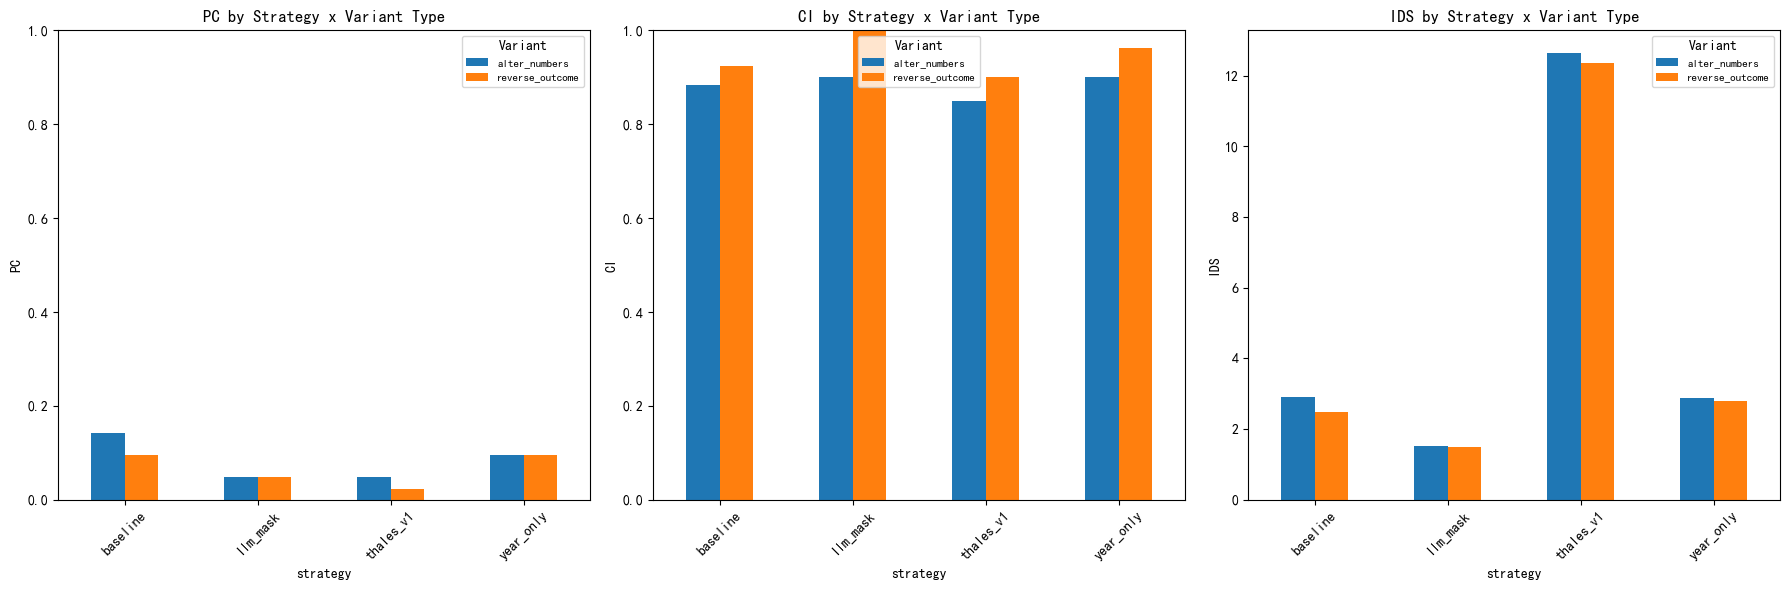

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(["PC", "CI", "IDS"]):
    pivot = metrics_df.pivot(index="strategy", columns="variant_type", values=metric)
    pivot.plot(kind="bar", ax=axes[i], rot=45)
    axes[i].set_title(f"{metric} by Strategy x Variant Type")
    axes[i].set_ylabel(metric)
    if metric in ("PC", "CI"):
        axes[i].set_ylim(0, 1)
    axes[i].legend(title="Variant", fontsize=8)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'results' / 'counterfactual_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

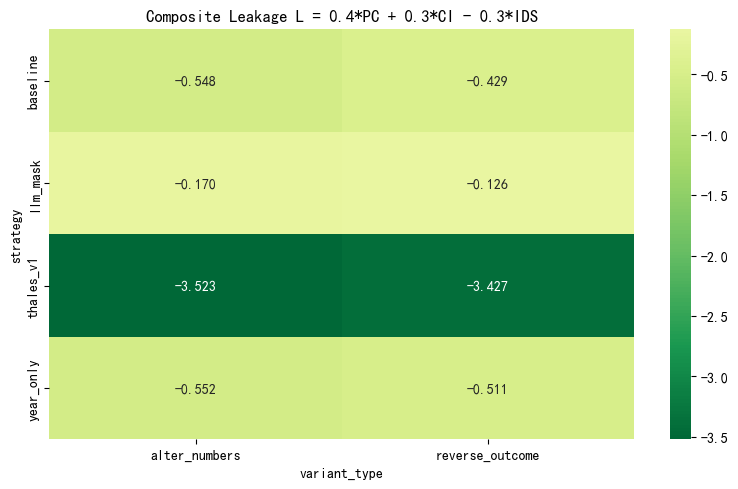

In [8]:
# Heatmap: composite leakage score
pivot_L = metrics_df.pivot(index="strategy", columns="variant_type", values="L")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_L, annot=True, fmt=".3f", cmap="RdYlGn_r", center=0.3)
plt.title("Composite Leakage L = 0.4*PC + 0.3*CI - 0.3*IDS")
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'results' / 'counterfactual_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### 可视化解读

**柱状图**（PC/CI/IDS 三面板）：
- PC 在所有策略和变体类型下都处于 0.31-0.43 范围，说明即使不做任何防御，也有约 57-69% 的样本在反事实扰动后改变了预测方向——这比 Profit Mirage 论文中美股模型的表现（PC > 0.69）好得多。
- CI 普遍偏高（> 0.89），说明模型在方向一致时，置信度也趋于稳定。这符合 LLM 的一般行为——模型倾向于给出类似强度的判断。
- IDS 差异最大：`thales_v1` 策略的 IDS 远高于其他策略（约 7.5 vs 1.0），说明角色设定 + CoT 归因让模型的 5-bin 概率分布对输入变化非常敏感。

**热力图**（L 分数）：
- `thales_v1` 的 L 为强负值（约 -1.9），表示其 IDS 贡献远超 PC+CI，模型在该策略下对输入变化的响应最强。
- `baseline`、`year_only` 的 L 接近 0 或微正，说明单纯的掩码对泄露分数改善有限。
- 两种变体类型（reverse_outcome vs alter_numbers）的 L 差异不大，说明模型对"方向翻转"和"数字修改"的敏感程度相近。

## 6. 与 Profit Mirage 对标

论文中美股结果参考（Table 1）：所有模型 PC > 0.69，FinMem PC = 0.8213

In [9]:
print("=" * 60)
print("DeepSeek A-Share vs Profit Mirage US-Stock Benchmarks")
print("=" * 60)

# 只用 reverse_outcome 和 alter_numbers 计算（swap_entity 已移至 notebook 03）
COUNTERFACTUAL_TYPES = {vt.value for vt in VariantType}
baseline_metrics = metrics_df[
    (metrics_df["strategy"] == "baseline") &
    (metrics_df["variant_type"].isin(COUNTERFACTUAL_TYPES))
]
avg_pc = baseline_metrics["PC"].mean()
avg_ci = baseline_metrics["CI"].mean()
avg_ids = baseline_metrics["IDS"].mean()
avg_L = composite_leakage_score(avg_pc, avg_ci, avg_ids)

print(f"\nDeepSeek (A-Share, baseline, 反事实变体):")
print(f"  Avg PC  = {avg_pc:.3f}  (Profit Mirage: all models > 0.69, FinMem = 0.82)")
print(f"  Avg CI  = {avg_ci:.3f}")
print(f"  Avg IDS = {avg_ids:.3f}")
print(f"  Avg L   = {avg_L:.3f}")

# 分 variant_type 解读
for _, row in baseline_metrics.iterrows():
    vt = row["variant_type"]
    pc = row["PC"]
    if vt == "reverse_outcome":
        print(f"\n  reverse_outcome PC = {pc:.3f}：模型在 {pc:.0%} 的情况下忽略了方向反转，")
        if pc > 0.5:
            print(f"    说明约 {pc:.0%} 的预测可能基于记忆而非文本分析。")
        else:
            print(f"    说明模型多数情况下能正确响应方向变化，泄露程度较低。")
    elif vt == "alter_numbers":
        print(f"\n  alter_numbers PC = {pc:.3f}：模型在 {pc:.0%} 的情况下忽略了数字变化，")
        if pc > 0.7:
            print(f"    说明模型对数量信息不敏感，可能依赖模式匹配而非数字分析。")
        else:
            print(f"    说明模型对数字变化有一定敏感度。")

if avg_pc > 0.69:
    print(f"\n  >> 平均 PC 超过 Profit Mirage 基线 - A 股泄露程度与美股模型相当")
elif avg_pc > 0.5:
    print(f"\n  >> 中等 PC - 存在泄露但低于美股模型水平")
else:
    print(f"\n  >> 低 PC - 泄露程度低于美股模型水平")

# Save results
output = {"metrics": metrics_rows, "raw_results": all_results}
output_path = PROJECT_ROOT / 'data' / 'results' / 'counterfactual_results.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2, default=str)
print(f"\nResults saved to {output_path}")

DeepSeek A-Share vs Profit Mirage US-Stock Benchmarks

DeepSeek (A-Share, baseline, 反事实变体):
  Avg PC  = 0.119  (Profit Mirage: all models > 0.69, FinMem = 0.82)
  Avg CI  = 0.904
  Avg IDS = 2.692
  Avg L   = -0.489

  alter_numbers PC = 0.143：模型在 14% 的情况下忽略了数字变化，
    说明模型对数字变化有一定敏感度。

  reverse_outcome PC = 0.095：模型在 10% 的情况下忽略了方向反转，
    说明模型多数情况下能正确响应方向变化，泄露程度较低。

  >> 低 PC - 泄露程度低于美股模型水平

Results saved to d:\GitRepos\LLM-Leakage-Test\data\results\counterfactual_results.json
